In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)
import json, os

df = pd.read_csv('../data/raw/rice.csv')
print(df.shape)
df.head()


(3810, 8)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


In [2]:

df['Class_encoded'] = df['Class'].astype('category').cat.codes


In [3]:
X = df.drop(columns=['Class', 'Class_encoded'])
y = df['Class_encoded']

# Fixed split shared by ALL member notebooks so results are directly comparable
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (3048, 7)  Test: (762, 7)


In [4]:
#Hyperparameter tuning with GridSearchCV (5-fold)
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
print("Best params:", best_params)


Best params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}


In [5]:
#K-fold cross-validation on the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy')
print("CV accuracy per fold:", cv_scores.round(4))
print(f"CV mean accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


CV accuracy per fold: [0.8918 0.9164 0.9049 0.8834 0.9048]
CV mean accuracy: 0.9003 (+/- 0.0115)


Test Accuracy  : 0.8793
Test Precision : 0.8723
Test Recall    : 0.9243
Test F1-score  : 0.8976

              precision    recall  f1-score   support

      Cammeo       0.89      0.82      0.85       326
    Osmancik       0.87      0.92      0.90       436

    accuracy                           0.88       762
   macro avg       0.88      0.87      0.88       762
weighted avg       0.88      0.88      0.88       762



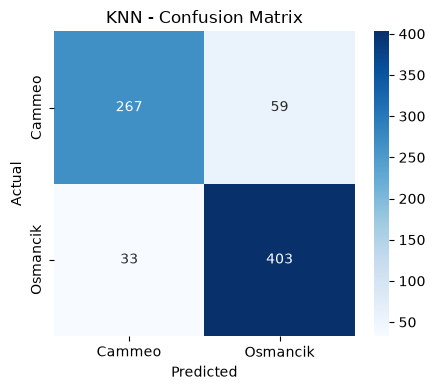

In [6]:
# Evaluate on the held-out test set
pos_val = 1  

y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=pos_val)
rec = recall_score(y_test, y_pred, pos_label=pos_val)
f1 = f1_score(y_test, y_pred, pos_label=pos_val)

print(f"Test Accuracy  : {acc:.4f}")
print(f"Test Precision : {prec:.4f}")
print(f"Test Recall    : {rec:.4f}")
print(f"Test F1-score  : {f1:.4f}\n")

print(classification_report(y_test, y_pred, target_names=['Cammeo', 'Osmancik']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cammeo', 'Osmancik'], yticklabels=['Cammeo', 'Osmancik'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN - Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/knn_confusion_matrix.png', dpi=150)
plt.show()

In [7]:
#Save results for the group comparison notebook
os.makedirs('../results/logs', exist_ok=True)
results = {
    'member': 'IT25103179',
    'model': 'KNN',
    'best_params': best_params,
    'cv_mean_accuracy': round(float(cv_scores.mean()), 4),
    'cv_std_accuracy': round(float(cv_scores.std()), 4),
    'test_accuracy': round(float(acc), 4),
    'test_precision': round(float(prec), 4),
    'test_recall': round(float(rec), 4),
    'test_f1': round(float(f1), 4),
}
with open('../results/logs/Member2_KNN_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))


{
  "member": "IT25103179",
  "model": "KNN",
  "best_params": {
    "metric": "manhattan",
    "n_neighbors": 5,
    "weights": "uniform"
  },
  "cv_mean_accuracy": 0.9003,
  "cv_std_accuracy": 0.0115,
  "test_accuracy": 0.8793,
  "test_precision": 0.8723,
  "test_recall": 0.9243,
  "test_f1": 0.8976
}
